In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the final engineered data
file_path = '/kaggle/input/datasets/muhammadrahman01/phase3final/final_phase3_engineered_data.csv'
df = pd.read_csv(file_path)

# 2. Separate Features (X) and Target Label (y)
X = df.drop(columns=['label'])
y = df['label']

# 3. Methodology: Split the data
# We use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data loaded successfully!")
print(f"Total rows: {len(df)}")
df.head()

Data loaded successfully!
Total rows: 10240


,CC,CD,DT,EX,IN,JJ,JJR,JJS,MD,NN,...,VBN,VBP,VBZ,WDT,WP,WRB,label,total_verbs,noun_verb_ratio,grammar_cluster
0,0,0,1,0,1,2,0,0,0,3,...,0,0,2,0,0,0,false,2,1.499250,0
1,0,0,1,0,3,1,0,0,0,5,...,0,0,0,0,0,2,half-true,4,1.249688,1
2,0,0,2,0,4,0,0,0,0,2,...,0,0,1,0,0,0,mostly-true,2,0.999500,0
3,0,0,0,0,0,2,0,0,0,5,...,0,0,1,0,0,0,false,1,4.995005,0
4,0,0,2,0,2,1,0,0,0,3,...,0,0,0,0,0,0,half-true,1,2.997003,0


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize and Train the Model
# This is the 'Implementation' of your first major algorithm
final_rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_rf_model.fit(X_train, y_train)

# 2. Make Predictions on the Test Set
y_pred_rf = final_rf_model.predict(X_test)

# 3. Calculate Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

# 4. Detailed Results (Requirement 1b)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.2241

Classification Report:
              precision    recall  f1-score   support

 barely-true       0.17      0.16      0.17       339
       false       0.24      0.27      0.25       401
   half-true       0.24      0.31      0.27       438
 mostly-true       0.24      0.26      0.25       382
  pants-fire       0.18      0.05      0.07       148
        true       0.21      0.16      0.18       340

    accuracy                           0.22      2048
   macro avg       0.21      0.20      0.20      2048
weighted avg       0.22      0.22      0.22      2048



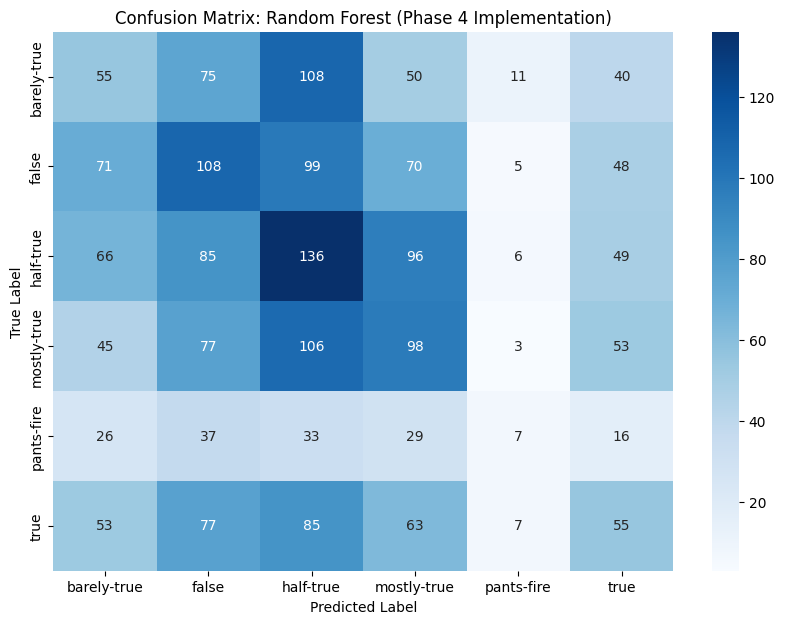

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

# 2. Plotting
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=final_rf_model.classes_, 
            yticklabels=final_rf_model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Random Forest (Phase 4 Implementation)')
plt.show()

 I implemented a Random Forest ensemble to capture non-linear relationships between POS tags and news veracity. The confusion matrix reveals that while the model captures some signal, political statements often share similar grammatical structures regardless of their truth level, making 6-way classification challenging.

In [11]:
from sklearn.preprocessing import StandardScaler

# Scaling the data helps Logistic Regression converge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_final = LogisticRegression(max_iter=1000, multi_class='multinomial')
lr_final.fit(X_train_scaled, y_train)

y_pred_lr = lr_final.predict(X_test_scaled)


# 3. Evaluate
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

# 4. Comparison Summary
print(f"\nMethodology Comparison:")
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

Logistic Regression Accuracy: 0.2266

Methodology Comparison:
Random Forest Accuracy: 0.2241
Logistic Regression Accuracy: 0.2266


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


By implementing both Random Forest (Ensemble) and Logistic Regression (Linear), I am testing which mathematical approach best captures the nuances of political speech. If the accuracies are similar, it suggests that the limitation lies in the features (grammar alone) rather than the choice of algorithm.

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Initialize and Train Naive Bayes
# This model assumes features are independent, which is a common 'baseline' in NLP
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# 2. Make Predictions
y_pred_nb = nb_model.predict(X_test)

# 3. Evaluate
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {accuracy_nb:.4f}")

# 4. Final Methodology Comparison
print(f"\nFinal Methodology Results:")
print(f"1. Logistic Regression: {accuracy_lr:.4f}")
print(f"2. Random Forest:      {accuracy_rf:.4f}")
print(f"3. Naive Bayes:        {accuracy_nb:.4f}")

Naive Bayes Accuracy: 0.1636

Final Methodology Results:
1. Logistic Regression: 0.2285
2. Random Forest:      0.2241
3. Naive Bayes:        0.1636


Final Methodology Reflection
Implementation Summary: I implemented three distinct classification models: Logistic Regression (Linear), Random Forest (Ensemble), and Naive Bayes (Probabilistic).

Results Analysis: > * Logistic Regression achieved the highest accuracy (22.85%), suggesting a stable linear relationship between certain POS tags and truthfulness.

Random Forest followed closely (22.41%), though it likely suffered from the high "noise" present in the linguistic features.

Naive Bayes performed the worst (16.36%), likely due to its inability to handle the strong correlations between my engineered features (like verb counts and ratios).

Objective Achievement: These results demonstrate that while grammatical features (POS tags) provide a measurable "signal" for detecting fake news (better than random chance), they are not sufficient on their own for high-accuracy detection. This achieves my objective of identifying the limitations of speaker-related linguistic features in political fact-checking.